In [4]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(clubSandwich)
library(lme4)
library(clubSandwich)
library(ggpubr)
library(patchwork)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'clubSandwich':
  method    from    
  bread.mlm sandwich

Loading required package: Matrix



In [1]:
#cnv_summary <- read.delim2("/home/mjehangir/telomere-sv-analysis/data//cnvs_summary_rate_prop_pq.tsv", header = TRUE)
cnv_summary <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/wakhan_cnvs_summary_rate_prop_pq.tsv", header = TRUE)

head(cnv_summary)

,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1,NA,Loss,NA,30.999999,1,NA,NA,NA,chr1NA
2,2436A,chr10,q,Loss,94108943,18.647833,5,94.108943,0.0531299134876055,0.198151550804263,chr10q
3,2436A,chr10,NA,Loss,NA,3.999999,1,NA,NA,NA,chr10NA
4,2436A,chr11,p,Loss,52743313,0.000611,1,52.743313,0.01895974945677,1.15844069180865e-05,chr11p
5,2436A,chr11,NA,Loss,NA,3.999999,1,NA,NA,NA,chr11NA
6,2436A,chr12,NA,Loss,NA,4.999999,1,NA,NA,NA,chr12NA


In [2]:
telomere_data <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/telomere_data_fig3_cnvs.tsv", header = TRUE)
head(telomere_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1p,5221,1,p,5.221,Negative,Other
2,2436A,chr1q,5051.16666666667,1,q,5.05116666666667,Negative,Other
3,3188,chr1p,1642.5,1,p,1.6425,Negative,Short TL
4,3188,chr1q,3086.5,1,q,3.0865,Negative,Short TL
5,3988,chr1p,2347.5,1,p,2.3475,Negative,Other
6,3988,chr1q,5083,1,q,5.083,Negative,Other


In [5]:
# Ensure both datasets have matching 'arm' column format
cnv_data <- cnv_summary %>%
  mutate(arm = paste0(chrom, Arm))  # e.g., "chr10q"

# Merge based on sample ID and arm
merged_cnv_data <- cnv_data %>%
  left_join(telomere_data, by = c("ID" = "Sample_prefix", "arm" = "chr")) %>%
  filter(!is.na(final_average_TL_p75))  # Filter out rows with missing telomere info

# View result
head(merged_cnv_data)


,ID,chrom,Arm,Gain_Loss,Arm_Length,total_cnv_length,segment_count,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr10,q,Loss,94108943,18.647833,5,94.108943,0.0531299134876055,0.198151550804263,chr10q,2732.75,10,q,2.73275,Positive,Other
2,2436A,chr11,p,Loss,52743313,0.000611,1,52.743313,0.01895974945677,1.15844069180865e-05,chr11p,6766,11,p,6.766,Negative,Other
3,2436A,chr18,q,Loss,62092914,0.400654,1,62.092914,0.0161048972512387,0.00645249150329778,chr18q,3629.5,18,q,3.6295,Positive,Other
4,2436A,chr4,p,Loss,52452474,3.999999,1,52.452474,0.0190648776643024,0.0762594915923318,chr4p,5788.25,4,p,5.78825,Negative,Other
5,3188,chr1,p,Loss,124048267,119.99999,11,124.048267,0.0886751606130862,0.967365307892612,chr1p,1642.5,1,p,1.6425,Negative,Short TL
6,3188,chr10,q,Loss,94108943,43.493116,6,94.108943,0.0637558961851266,0.462157098077278,chr10q,3496.5,10,q,3.4965,Positive,Short TL


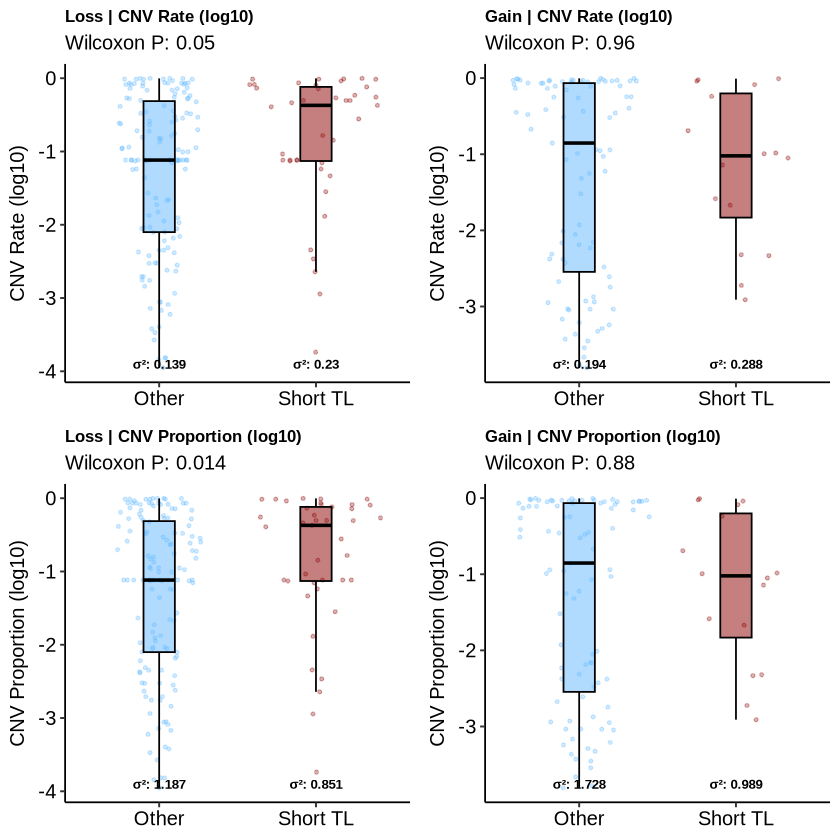

In [6]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(ggforce)

# 1. Transform Data: Numeric conversion + Log10 Transformation
# We use a small pseudo-count (0.0001) because rates are often < 1
merged_cnv_data <- merged_cnv_data %>%
  mutate(
    # Ensure numeric
    cnv_rate_num = as.numeric(as.character(cnv_rate_per_mb)),
    cnv_prop_num = as.numeric(as.character(cnv_proportion_per_mb)),
    
    # Log transformation (log10(x + small_constant))
    cnv_rate_log = log10(cnv_rate_num + 0.0001),
    cnv_prop_log = log10(cnv_prop_num + 0.0001),
    
    # Standardize groups
    TL_group = factor(TL_group, levels = c("Other", "Short TL"))
  ) %>%
  filter(!is.na(cnv_rate_log))

# List of columns to plot
cnv_metrics <- c("cnv_rate_log", "cnv_prop_log")
cnv_types <- unique(merged_cnv_data$Gain_Loss) # Gain and Loss

# 2. Generate the Analysis & Plotting Loop
# This creates a plot for each Metric (Rate/Prop) across each Type (Gain/Loss)
plot_list <- list()

for (m in cnv_metrics) {
  for (t in cnv_types) {
    
    df_sub <- merged_cnv_data %>% filter(Gain_Loss == t)
    
    # Check if we have enough groups for Wilcoxon
    if(length(unique(df_sub$TL_group)) < 2) next
    
    # A. Statistics on Log-transformed data
    wt_res <- wilcox.test(get(m) ~ TL_group, data = df_sub)
    
    stats_summary <- df_sub %>%
      group_by(TL_group) %>%
      summarise(
        mean_val = mean(get(m), na.rm = TRUE),
        variance = var(get(m), na.rm = TRUE)
      )
    
    # B. The Plot
    metric_label <- if(grepl("rate", m)) "CNV Rate (log10)" else "CNV Proportion (log10)"
    
    p <- ggplot(df_sub, aes(x = TL_group, y = get(m), fill = TL_group)) +
      geom_sina(aes(color = TL_group), alpha = 0.3, size = 0.8) +
      geom_boxplot(width = 0.2, outlier.shape = NA, alpha = 0.5, color = "black") +
      
      # Label Variance
      geom_text(data = stats_summary, 
                aes(x = TL_group, y = -Inf, label = paste0("σ²: ", round(variance, 3))), 
                vjust = -1.5, size = 2.8, fontface = "bold", inherit.aes = FALSE) +
      
      labs(
        title = paste(t, "|", metric_label),
        subtitle = paste0("Wilcoxon P: ", format.pval(wt_res$p.value, digits = 2)),
        y = metric_label,
        x = NULL
      ) +
      scale_fill_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
      scale_color_manual(values = c("Other" = "steelblue1", "Short TL" = "darkred")) +
      theme_pubr() + 
      theme(legend.position = "none", plot.title = element_text(size = 10, face = "bold"))
    
    plot_list[[paste(m, t)]] <- p
  }
}

# 3. Arrange into a 2x2 grid
final_cnv_panel <- ggarrange(plotlist = plot_list, ncol = 2, nrow = 2)
print(final_cnv_panel)